### IDK i just follow GEMINI

In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

def load_dataset(file_path):
    """
    加载 NASA 原始数据并分配列名
    """
    # 固定的 26 个属性结构
    col_names = ['unit_nr', 'time_cycle', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
    return pd.read_csv(file_path, sep='\s+', header=None, names=col_names)

def build_train_rul(df, max_rul=125):
    """
    针对训练集生成 Piecewise RUL (分段线性标签)
    """
    max_cycle = df.groupby('unit_nr')['time_cycle'].max()
    df = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='unit_nr', right_index=True)
    remaining_cycle = df['max_cycle'] - df['time_cycle']
    df['RUL'] = remaining_cycle.apply(lambda x: x if x <= max_rul else max_rul)
    return df.drop(['max_cycle'], axis=1)

def build_test_rul(test_df, truth_file, max_rul=125):
    """
    针对测试集，结合上传的 RUL_FD001.txt 生成标签
    测试集每台机器只取最后一个时间点来预测
    """
    truth_rul = pd.read_csv(truth_file, header=None, names=['ground_truth'])
    truth_rul['unit_nr'] = range(1, len(truth_rul) + 1)
    
    # 找到测试集中每台机器的最后一个周期
    test_last_cycle = test_df.groupby('unit_nr')['time_cycle'].max().reset_index()
    test_last_cycle = test_last_cycle.merge(truth_rul, on='unit_nr')
    return test_last_cycle

def extract_slope(series):
    """
    计算曲率 (Gradient/Slope)
    """
    if len(series) < 2: return 0.0
    y = series.values.reshape(-1, 1)
    x = np.array(range(len(series))).reshape(-1, 1)
    return LinearRegression().fit(x, y).coef_[0][0]

def feature_engineering_pipeline(df, window_size=15, is_test=False, test_labels=None):
    """
    核心清洗与特征提取逻辑 (均值 + 标准差 + 曲率)
    """
    # 1. 自动清洗：剔除常数传感器
    # 这里的阈值设为 1e-5，如果一个传感器几乎不波动，说明没用
    sensor_cols = [f's_{i}' for i in range(1, 22)]
    useful_sensors = [col for col in sensor_cols if df[col].std() > 1e-5]
    
    # 2. 归一化 (针对通用性)
    scaler = MinMaxScaler()
    df[useful_sensors] = scaler.fit_transform(df[useful_sensors])
    
    processed_features = []
    labels = []
    
    for unit_id in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit_id].copy()
        
        # 如果是测试集，我们通常预测最后一个窗口
        if is_test:
            if len(unit_df) < window_size: continue
            window = unit_df.tail(window_size)
            feat_vector = []
            for col in useful_sensors:
                feat_vector.extend([window[col].mean(), window[col].std(), extract_slope(window[col])])
            processed_features.append(feat_vector)
            # 获取对应的真实 RUL
            actual_rul = test_labels[test_labels['unit_nr'] == unit_id]['ground_truth'].values[0]
            labels.append(actual_rul)
        else:
            # 训练集：滑动窗口遍历全寿命
            for i in range(window_size, len(unit_df)):
                window = unit_df.iloc[i-window_size:i]
                feat_vector = []
                for col in useful_sensors:
                    feat_vector.extend([window[col].mean(), window[col].std(), extract_slope(window[col])])
                processed_features.append(feat_vector)
                labels.append(unit_df.iloc[i]['RUL'])
    
    # 生成列名
    new_col_names = []
    for s in useful_sensors:
        new_col_names.extend([f'{s}_mean', f'{s}_std', f'{s}_slope'])
        
    final_df = pd.DataFrame(processed_features, columns=new_col_names)
    final_df['Target_RUL'] = labels
    return final_df

# --- 执行清洗与特征化 ---
# 1. 加载
df_train_raw = load_dataset("../data/train_FD001.txt")
df_test_raw = load_dataset("../data/test_FD001.txt")

# 2. 准备标签
df_train_labeled = build_train_rul(df_train_raw)
df_test_truth = build_test_rul(df_test_raw, "../data/RUL_FD001.txt")

# 3. 运行通用特征提取管道 (提取均值、标准差、曲率)
train_final = feature_engineering_pipeline(df_train_labeled, window_size=15, is_test=False)
test_final = feature_engineering_pipeline(df_test_raw, window_size=15, is_test=True, test_labels=df_test_truth)

print(f"训练集形状: {train_final.shape}")
print(f"测试集形状: {test_final.shape}")
print(train_final[['s_2_mean', 's_2_slope', 'Target_RUL']].head())

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_20408\1804866427.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  return pd.read_csv(file_path, sep='\s+', header=None, names=col_names)


训练集形状: (19131, 46)
测试集形状: (100, 46)
   s_2_mean  s_2_slope  Target_RUL
0  0.322289   0.006992       125.0
1  0.328514   0.001904       125.0
2  0.337149   0.002711       125.0
3  0.342570   0.005077       125.0
4  0.331325   0.000904       125.0


### SAVE IN GEMINI FILE

In [51]:
train_final.to_csv("../data/gemini/train_features.csv", index=False)
test_final.to_csv("../data/gemini/test_features.csv", index=False)

### DESCRIBE FILE

In [52]:
train_final.head()
test_final.head()


,s_2_mean,s_2_std,s_2_slope,s_3_mean,s_3_std,s_3_slope,s_4_mean,s_4_std,s_4_slope,s_6_mean,...,s_17_mean,s_17_std,s_17_slope,s_20_mean,s_20_std,s_20_slope,s_21_mean,s_21_std,s_21_slope,Target_RUL
0,0.389485,0.085272,-0.003222,0.442431,0.101989,0.002270,0.342182,0.062356,-0.004003,1.0,...,0.366667,0.099851,0.007589,0.590909,0.095036,-0.009123,0.619797,0.047304,-0.000916,112
1,0.506625,0.071477,-0.002265,0.524955,0.103000,-0.003223,0.447689,0.069410,0.006243,1.0,...,0.458333,0.102062,-0.013393,0.486667,0.086917,0.002955,0.508846,0.068082,-0.002778,98
2,0.562986,0.089184,-0.003752,0.632840,0.084086,-0.002373,0.613627,0.063452,-0.004084,1.0,...,0.583333,0.112467,0.009821,0.418182,0.121919,-0.008831,0.440991,0.068919,-0.007861,69
3,0.537539,0.081155,-0.001093,0.586826,0.069783,0.002113,0.531182,0.091224,0.004214,1.0,...,0.550000,0.123201,0.001786,0.438182,0.090205,-0.006883,0.469309,0.086426,-0.004718,82
4,0.498212,0.083108,0.002321,0.565446,0.084495,-0.001846,0.517432,0.089176,0.004975,1.0,...,0.566667,0.104226,-0.002232,0.444242,0.079019,-0.005292,0.445445,0.100668,0.010718,91


In [53]:
train_final.describe()
test_final.describe()

,s_2_mean,s_2_std,s_2_slope,s_3_mean,s_3_std,s_3_slope,s_4_mean,s_4_std,s_4_slope,s_6_mean,...,s_17_mean,s_17_std,s_17_slope,s_20_mean,s_20_std,s_20_slope,s_21_mean,s_21_std,s_21_slope,Target_RUL
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,0.498303,0.093513,0.002890,0.568081,0.106612,0.001302,0.514880,0.080717,0.002893,0.988000,...,0.536250,0.118393,0.004036,0.447903,0.090728,-0.003194,0.490077,0.085188,-0.002844,75.52000
std,0.109760,0.016623,0.006117,0.099486,0.020695,0.006596,0.140375,0.013906,0.004889,0.039503,...,0.131059,0.021363,0.007447,0.115365,0.019398,0.005376,0.105948,0.015152,0.005730,41.76497
min,0.277603,0.056880,-0.012900,0.363957,0.064064,-0.016644,0.224586,0.050585,-0.007785,0.733333,...,0.266667,0.074202,-0.013393,0.198182,0.046887,-0.014513,0.266034,0.047304,-0.016274,7.00000
25%,0.411462,0.082257,-0.001132,0.500355,0.092423,-0.003168,0.398635,0.068751,-0.000484,1.000000,...,0.433333,0.104226,-0.001339,0.376212,0.075418,-0.006737,0.424657,0.076856,-0.007624,32.75000
50%,0.490852,0.092524,0.002726,0.552047,0.105850,0.000801,0.504438,0.080394,0.002825,1.000000,...,0.516667,0.115728,0.003571,0.451515,0.091409,-0.002581,0.509134,0.083508,-0.003455,86.00000
75%,0.563775,0.104580,0.008070,0.634355,0.118656,0.006576,0.599517,0.089307,0.006032,1.000000,...,0.625000,0.129099,0.008929,0.527879,0.102784,0.000487,0.572003,0.091896,0.001759,112.25000
max,0.718612,0.148596,0.017575,0.817000,0.174604,0.016628,0.822830,0.122878,0.017132,1.000000,...,0.825000,0.194798,0.022768,0.715152,0.137003,0.009026,0.702647,0.127511,0.013298,145.00000


### Model Training

In [54]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def train_and_compare(train_df, test_df):
    # 1. 准备数据
    X_train = train_df.drop(['Target_RUL'], axis=1)
    y_train = train_df['Target_RUL']
    X_test = test_df.drop(['Target_RUL'], axis=1)
    y_test = test_df['Target_RUL']

    # 存储结果的列表
    performance_metrics = []

    def get_metrics(model, name, X_tr, y_tr, X_te, y_te):
        # 预测
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)
        
        # 计算各项指标
        metrics = {
            'Model': name,
            'Train RMSE': np.sqrt(mean_squared_error(y_tr, pred_tr)),
            'Test RMSE': np.sqrt(mean_squared_error(y_te, pred_te)),
            'Train MAE': mean_absolute_error(y_tr, pred_tr),
            'Test MAE': mean_absolute_error(y_te, pred_te),
            'Train R2': r2_score(y_tr, pred_tr),
            'Test R2': r2_score(y_te, pred_te)
        }
        return metrics, pred_te

    # --- 1. XGBoost (API 2.0+ 修复版) ---
    print("\n[1/3] 正在训练 XGBoost (已添加过拟合保护)...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,        # 较低的学习率更稳健
        max_depth=4,               # 限制树深防止过拟合
        subsample=0.7,             # 训练时只使用 70% 的数据，增加泛化力
        colsample_bytree=0.7,
        reg_alpha=0.5,             # L1 正则化
        reg_lambda=1.5,            # L2 正则化
        early_stopping_rounds=50,  # 新版本 API：在此定义
        random_state=42
    )
    
    # 注意：eval_set 依然在 fit 中提供
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_m, xgb_preds = get_metrics(xgb_model, "XGBoost", X_train, y_train, X_test, y_test)
    performance_metrics.append(xgb_m)

    # --- 2. LightGBM (修复版) ---
    print("[2/3] 正在训练 LightGBM...")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=20,             # 限制叶子节点数防止过拟合
        max_depth=5,
        lambda_l1=0.5,
        lambda_l2=1.5,
        bagging_fraction=0.7,
        bagging_freq=5,
        feature_fraction=0.7,
        random_state=42,
        importance_type='gain'
    )
    
    # LightGBM 早期停止通常通过 callbacks 或在 fit 中设置
    lgb_model.fit(
        X_train, y_train, 
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )
    lgb_m, lgb_preds = get_metrics(lgb_model, "LightGBM", X_train, y_train, X_test, y_test)
    performance_metrics.append(lgb_m)

    # --- 3. Ensemble (模型融合) ---
    print("[3/3] 计算融合模型 (Weighted Ensemble)...")
    # 简单的均值融合通常能极大地降低误差并防止过拟合
    ens_train_pred = (xgb_model.predict(X_train) + lgb_model.predict(X_train)) / 2
    ens_test_pred = (xgb_preds + lgb_preds) / 2
    
    ensemble_m = {
        'Model': 'Ensemble (XGB+LGB)',
        'Train RMSE': np.sqrt(mean_squared_error(y_train, ens_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, ens_test_pred)),
        'Train MAE': mean_absolute_error(y_train, ens_train_pred),
        'Test MAE': mean_absolute_error(y_test, ens_test_pred),
        'Train R2': r2_score(y_train, ens_train_pred),
        'Test R2': r2_score(y_test, ens_test_pred)
    }
    performance_metrics.append(ensemble_m)

    # --- 制作对比表格 ---
    metrics_df = pd.DataFrame(performance_metrics).set_index('Model')
    
    print("\n" + "="*35 + " 模型对比报告 " + "="*35)
    # 格式化显示
    display_df = metrics_df.style.background_gradient(cmap='viridis', axis=0).format(precision=2)
    print(metrics_df.round(2).to_string())
    print("="*85)

    # --- 可视化对比 ---
    plt.figure(figsize=(14, 6))
    plt.plot(y_test.values, label='Actual RUL', color='black', alpha=0.8, linewidth=2)
    plt.plot(ens_test_pred, label='Ensemble Predicted', color='red', linestyle='--', alpha=0.9)
    plt.fill_between(range(len(y_test)), y_test.values, ens_test_pred, color='red', alpha=0.1, label='Error Area')
    plt.title('Final Prediction Performance (Actual vs Predicted)', fontsize=14)
    plt.ylabel('Remaining Useful Life (Cycles)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return metrics_df, xgb_model, lgb_model

# 调用示例
# metrics_table, final_xgb, final_lgb = train_and_compare(train_final, test_final)


[1/3] 正在训练 XGBoost (已添加过拟合保护)...
[2/3] 正在训练 LightGBM...
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=1.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=1.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.5
[LightGBM] [Warning] bagging_fraction is set=0.7, subsam

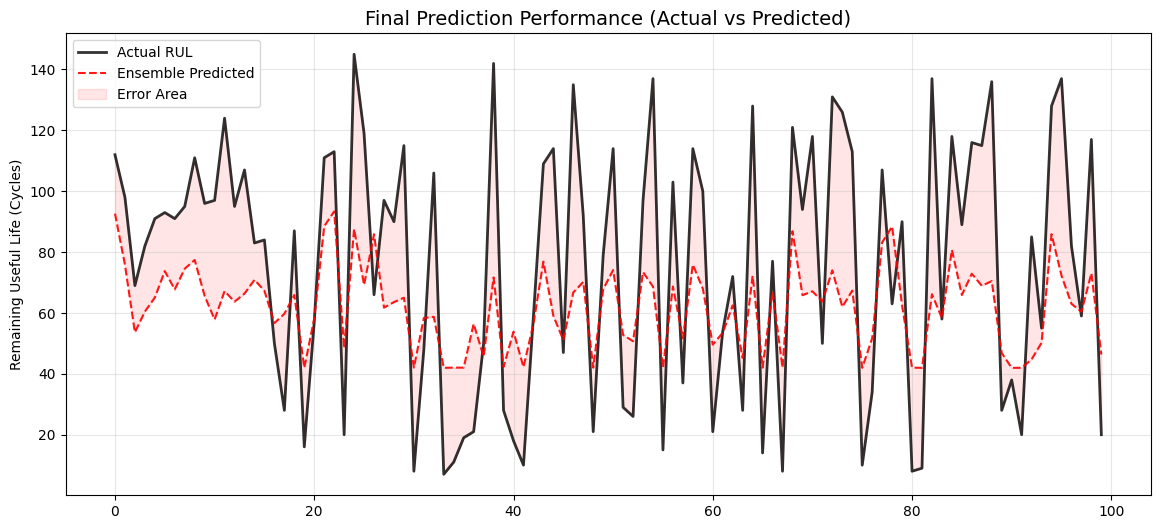

                    Train RMSE  Test RMSE  Train MAE   Test MAE  Train R2  \
Model                                                                       
XGBoost              25.893989  33.929527  23.414602  29.484184  0.616856   
LightGBM             25.048381  34.812825  22.636917  30.247514  0.641472   
Ensemble (XGB+LGB)   25.461480  34.355303  23.021029  29.844020  0.629549   

                     Test R2  
Model                         
XGBoost             0.333353  
LightGBM            0.298191  
Ensemble (XGB+LGB)  0.316517  


In [55]:
metrics_table, final_xgb, final_lgb = train_and_compare(train_final, test_final)
print(metrics_table)